# Preprocessing


## Imports and adding the data



In [87]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from datetime import datetime, timedelta
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [9]:
#Shakl plotting wahed
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
data = "/content/drive/MyDrive/gluroo-data-export-2025-09-07_2025-12-06.csv"

try:
    df = pd.read_csv(data)
    print("CSV file loaded from Google Drive successfully")
except FileNotFoundError:
    print(f"Error: The file at '{data}' was not found. Please ensure the path is correct.")
except Exception as e:
    print(f"An error occurred while reading the CSV from Drive: {e}")

CSV file loaded from Google Drive successfully


## Data Exploration

In [12]:
df.head(5)

,date,bgl,trend,eventType,senderId,text,template,msgType,affectsFob,affectsIob,...,foodFat,foodProtein,foodSalt,foodCal,doseAutomatic,description,fpBgl,actionMins,exerciseMins,exerciseLevel
0,2025-09-07T20:37:57+00:00,131,FORTYFIVE_UP,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-07T20:49:23+00:00,134,FLAT,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-09-07T20:50:24+00:00,136,FORTYFIVE_UP,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-09-07T20:53:25+00:00,147,FORTYFIVE_UP,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-09-07T20:56:25+00:00,157,SINGLE_UP,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.tail(5)

,date,bgl,trend,eventType,senderId,text,template,msgType,affectsFob,affectsIob,...,foodFat,foodProtein,foodSalt,foodCal,doseAutomatic,description,fpBgl,actionMins,exerciseMins,exerciseLevel
44324,2025-12-06T21:26:16+00:00,243,FLAT,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44325,2025-12-06T21:28:18+00:00,242,FLAT,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44326,2025-12-06T21:30:19+00:00,244,FLAT,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44327,2025-12-06T21:33:20+00:00,244,FLAT,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44328,2025-12-06T21:34:19+00:00,245,FLAT,cgm_reading,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
print("\n Data Info:")
print(f"   Columns: {list(df.columns)}")
print(f"\n Data Types:")
print(df.dtypes)


 Data Info:
   Columns: ['date', 'bgl', 'trend', 'eventType', 'senderId', 'text', 'template', 'msgType', 'affectsFob', 'affectsIob', 'doseUnits', 'foodG', 'foodSugar', 'foodFat', 'foodProtein', 'foodSalt', 'foodCal', 'doseAutomatic', 'description', 'fpBgl', 'actionMins', 'exerciseMins', 'exerciseLevel']

 Data Types:
date              object
bgl                int64
trend             object
eventType         object
senderId         float64
text              object
template          object
msgType           object
affectsFob        object
affectsIob        object
doseUnits        float64
foodG            float64
foodSugar        float64
foodFat          float64
foodProtein      float64
foodSalt         float64
foodCal          float64
doseAutomatic     object
description      float64
fpBgl            float64
actionMins       float64
exerciseMins     float64
exerciseLevel    float64
dtype: object


In [15]:
df.describe()

,bgl,senderId,doseUnits,foodG,foodSugar,foodFat,foodProtein,foodSalt,foodCal,description,fpBgl,actionMins,exerciseMins,exerciseLevel
count,44329.000000,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,194.933633,-0.200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,62.888231,0.421637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,40.000000,-1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,150.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,194.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,239.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,419.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Checking the missing values

In [16]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing Count': missing_count.values,
    'Missing Percentage': missing_pct.values
}).sort_values('Missing Percentage', ascending=False)

print("\nMissing Values Summary:")
print(missing_df.to_string(index=False))


Missing Values Summary:
       Column  Missing Count  Missing Percentage
      foodCal          44329          100.000000
  description          44329          100.000000
  foodProtein          44329          100.000000
        foodG          44329          100.000000
    foodSugar          44329          100.000000
      foodFat          44329          100.000000
    doseUnits          44329          100.000000
 exerciseMins          44329          100.000000
   actionMins          44329          100.000000
exerciseLevel          44329          100.000000
        fpBgl          44329          100.000000
     foodSalt          44329          100.000000
     template          44321           99.981953
         text          44319           99.977441
     senderId          44319           99.977441
   affectsFob          44319           99.977441
      msgType          44319           99.977441
   affectsIob          44319           99.977441
doseAutomatic          44319           99.97

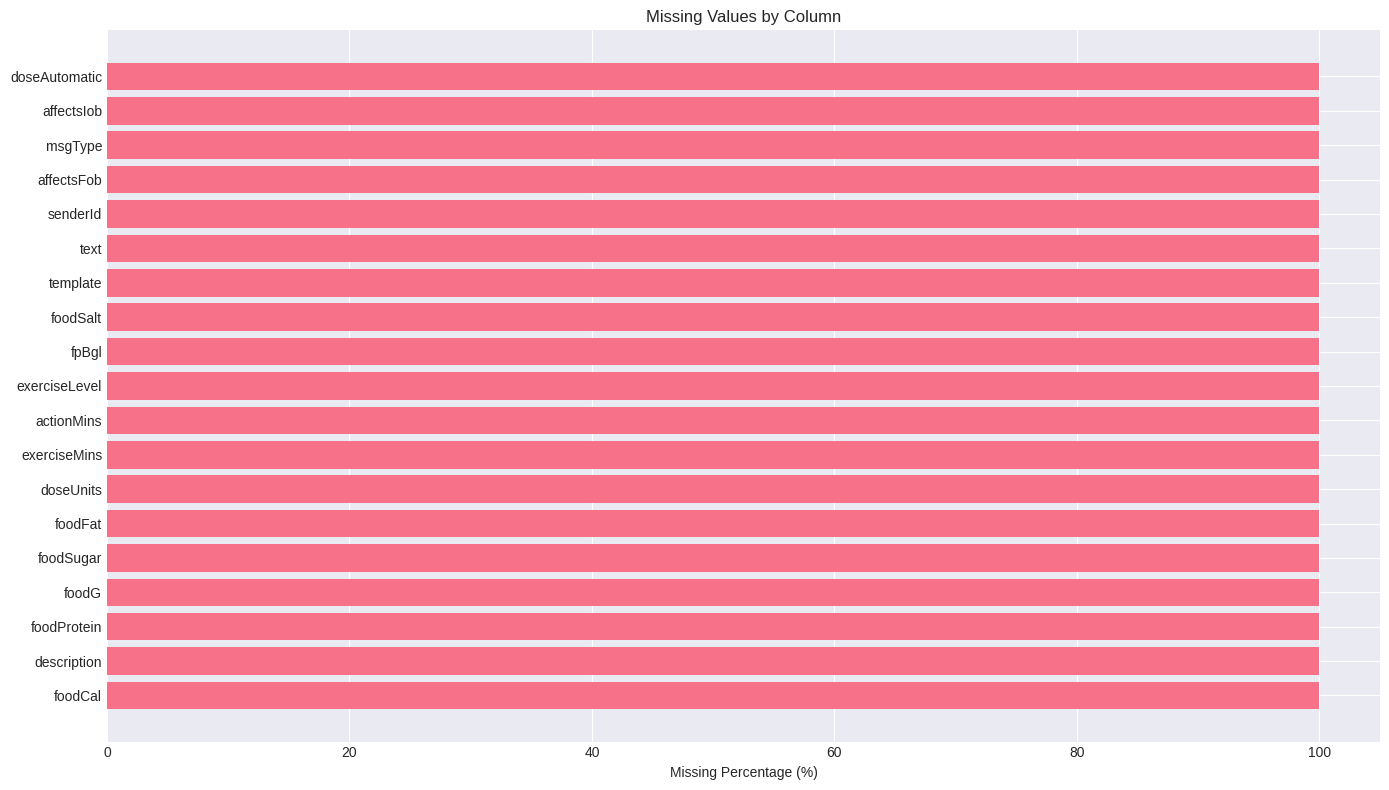

In [17]:
plt.figure(figsize=(14, 8))
missing_df_plot = missing_df[missing_df['Missing Percentage'] > 0]
if len(missing_df_plot) > 0:
    plt.barh(missing_df_plot['Column'], missing_df_plot['Missing Percentage'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

In [18]:
# feh columns fehaa missing values over ya3ny fo2 el 90% fa malhomsh lazma
high_missing_cols = missing_df[missing_df['Missing Percentage'] > 90]['Column'].tolist()
print(f"\n Columns with >90% missing values: {len(high_missing_cols)}")
print(f"   {high_missing_cols}")


 Columns with >90% missing values: 19
   ['foodCal', 'description', 'foodProtein', 'foodG', 'foodSugar', 'foodFat', 'doseUnits', 'exerciseMins', 'actionMins', 'exerciseLevel', 'fpBgl', 'foodSalt', 'template', 'text', 'senderId', 'affectsFob', 'msgType', 'affectsIob', 'doseAutomatic']


## Data Cleaning

In [19]:
# han5aly el data el mohema bs w hansheel el ba2y
essential_cols = ['date', 'bgl', 'trend', 'eventType']
cols_to_drop = [col for col in df.columns if col not in essential_cols]

print(f"Columns to drop: {len(cols_to_drop)}")
print(f"  {cols_to_drop}")

Columns to drop: 19
  ['senderId', 'text', 'template', 'msgType', 'affectsFob', 'affectsIob', 'doseUnits', 'foodG', 'foodSugar', 'foodFat', 'foodProtein', 'foodSalt', 'foodCal', 'doseAutomatic', 'description', 'fpBgl', 'actionMins', 'exerciseMins', 'exerciseLevel']


In [20]:
df_clean = df[essential_cols].copy()
print(f"\n✓ Cleaned dataset shape: {df_clean.shape}")
print(f"  Remaining columns: {list(df_clean.columns)}")



✓ Cleaned dataset shape: (44329, 4)
  Remaining columns: ['date', 'bgl', 'trend', 'eventType']


## Date and Time Processing


In [21]:
df_clean['date'] = pd.to_datetime(df_clean['date'], format='ISO8601', errors='coerce')


In [22]:
invalid_dates = df_clean['date'].isnull().sum()
if invalid_dates > 0:
    print(f"⚠ Warning: {invalid_dates} invalid dates found. Removing them...")
    df_clean = df_clean.dropna(subset=['date'])

In [23]:
print(f"\nDate Range:")
print(f"  Start: {df_clean['date'].min()}")
print(f"  End: {df_clean['date'].max()}")
print(f"  Duration: {(df_clean['date'].max() - df_clean['date'].min()).days} days")
print(f"  Total records: {len(df_clean):,}")



Date Range:
  Start: 2025-09-07 20:37:57+00:00
  End: 2025-12-06 21:34:19+00:00
  Duration: 90 days
  Total records: 44,329


## Duplicates checking

In [24]:
duplicates = df_clean.duplicated(subset=['date'], keep=False).sum()
print(f"\nDuplicate timestamps: {duplicates}")
if duplicates > 0:
    print("  Removing duplicates (keeping first occurrence)...")
    df_clean = df_clean.drop_duplicates(subset=['date'], keep='first')
    print(f"  Records after deduplication: {len(df_clean):,}")



Duplicate timestamps: 2
  Removing duplicates (keeping first occurrence)...
  Records after deduplication: 44,328


In [25]:
duplicates = df_clean.duplicated(subset=['date'], keep=False).sum()
print(f"\nDuplicate timestamps: {duplicates}")


Duplicate timestamps: 0


### sorting dates

In [26]:
df_clean = df_clean.sort_values('date').reset_index(drop=True)
print(f"\n Data sorted by timestamp")


 Data sorted by timestamp


# Blood Glucose Level Analysis (BGL)

In [27]:
bgl_stats = df_clean['bgl'].describe()
print(bgl_stats)

count    44328.000000
mean       194.934556
std         62.888640
min         40.000000
25%        150.000000
50%        194.000000
75%        239.000000
max        419.000000
Name: bgl, dtype: float64


In [28]:
print(f"\nAdditional Statistics:")
print(f"  Median: {df_clean['bgl'].median():.2f} mg/dL")
print(f"  Mode: {df_clean['bgl'].mode().values[0] if len(df_clean['bgl'].mode()) > 0 else 'N/A'} mg/dL")
print(f"  Unique values: {df_clean['bgl'].nunique()}")


Additional Statistics:
  Median: 194.00 mg/dL
  Mode: 194 mg/dL
  Unique values: 344


## Medical references

1. Normal fasting: 70-100 mg/dL
2. Normal post-meal: <140 mg/dL
3. Pre-diabetic: 100-125 mg/dL (fasting)
4. Diabetic: >125 mg/dL (fasting) or >200 mg/dL (random)

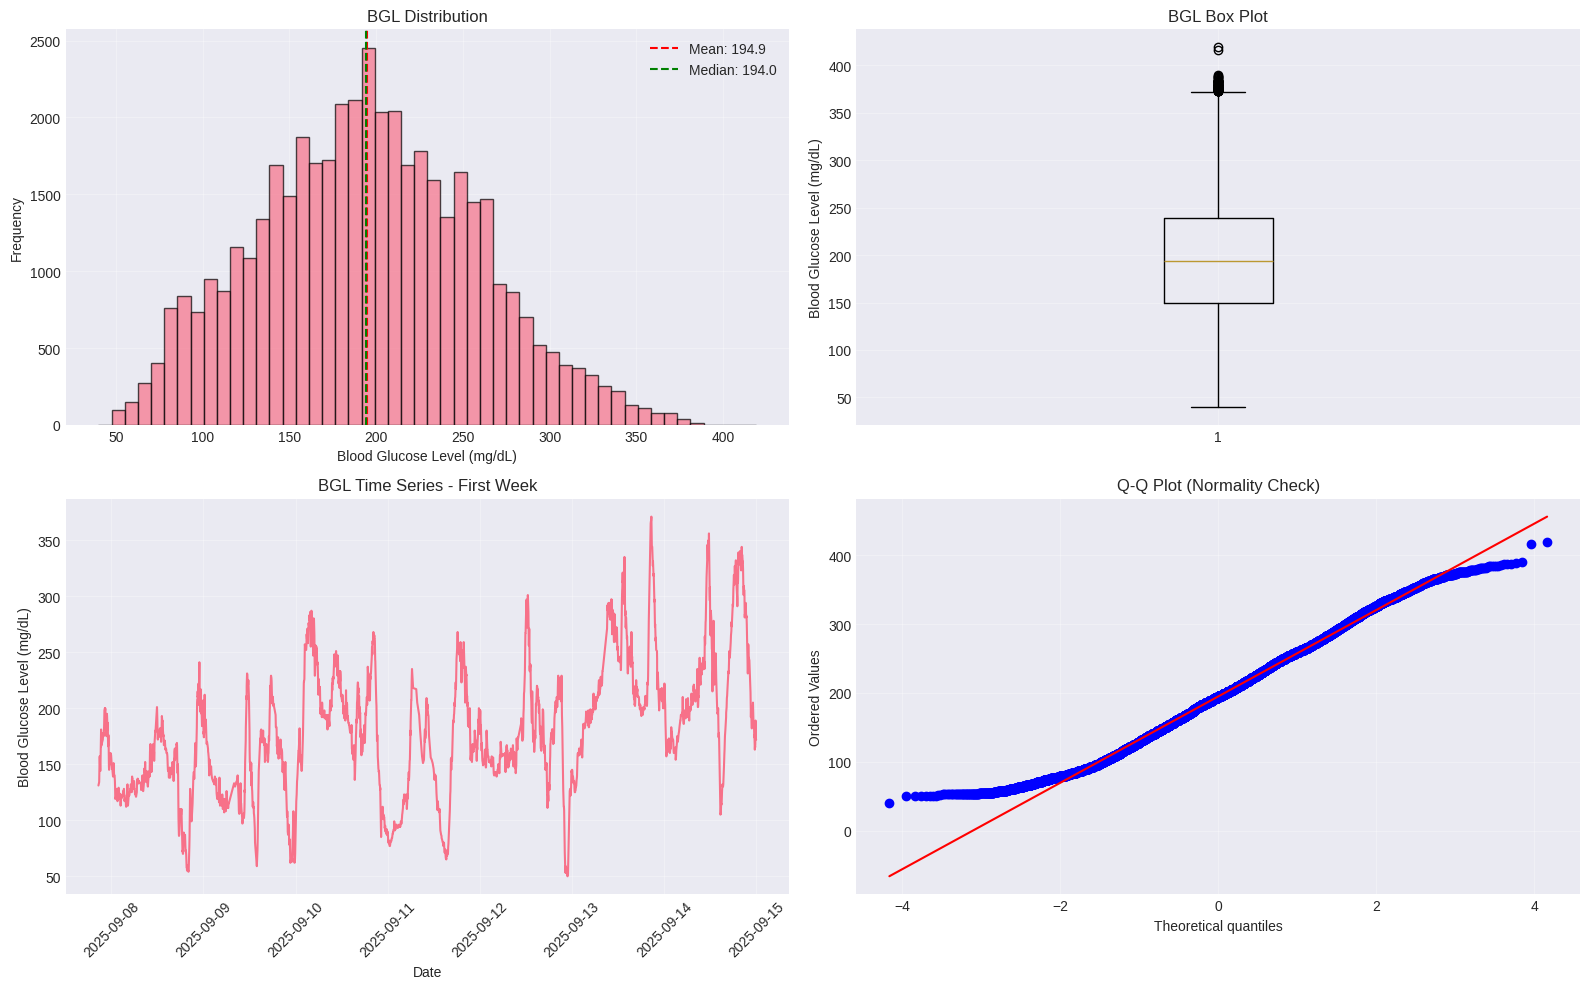

In [29]:
#Histogram
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].hist(df_clean['bgl'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_clean['bgl'].mean(), color='r', linestyle='--', label=f'Mean: {df_clean["bgl"].mean():.1f}')
axes[0, 0].axvline(df_clean['bgl'].median(), color='g', linestyle='--', label=f'Median: {df_clean["bgl"].median():.1f}')
axes[0, 0].set_xlabel('Blood Glucose Level (mg/dL)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('BGL Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
# Box plot
axes[0, 1].boxplot(df_clean['bgl'], vert=True)
axes[0, 1].set_ylabel('Blood Glucose Level (mg/dL)')
axes[0, 1].set_title('BGL Box Plot')
axes[0, 1].grid(True, alpha=0.3)

# Time series plot (first week)
df_clean_indexed = df_clean.set_index('date')
first_week = df_clean_indexed['bgl']['2025-09-07':'2025-09-14']
axes[1, 0].plot(first_week.index, first_week.values, linewidth=1.5)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Blood Glucose Level (mg/dL)')
axes[1, 0].set_title('BGL Time Series - First Week')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Q-Q plot for normality check
from scipy import stats
stats.probplot(df_clean['bgl'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Outliers Detection and Handling
### Medical bounds (physiologically reasonable range)
1. MEDICAL_MIN = 40  -> Severe hypoglycemia threshold

2. MEDICAL_MAX = 400 -> Severe hyperglycemia threshold

In [30]:
MEDICAL_MIN = 40
MEDICAL_MAX = 400

In [31]:
Q1 = df_clean['bgl'].quantile(0.25)
Q3 = df_clean['bgl'].quantile(0.75)
IQR = Q3 - Q1
LOWER_BOUND = Q1 - 1.5 * IQR
UPPER_BOUND = Q3 + 1.5 * IQR


In [32]:
print(f"  Minimum: {MEDICAL_MIN} mg/dL")
print(f"  Maximum: {MEDICAL_MAX} mg/dL")

  Minimum: 40 mg/dL
  Maximum: 400 mg/dL


In [33]:
print(f"  Q1: {Q1:.2f} mg/dL")
print(f"  Q3: {Q3:.2f} mg/dL")
print(f"  IQR: {IQR:.2f} mg/dL")
print(f"  Lower bound: {LOWER_BOUND:.2f} mg/dL")
print(f"  Upper bound: {UPPER_BOUND:.2f} mg/dL")

  Q1: 150.00 mg/dL
  Q3: 239.00 mg/dL
  IQR: 89.00 mg/dL
  Lower bound: 16.50 mg/dL
  Upper bound: 372.50 mg/dL


In [34]:
medical_outliers = df_clean[(df_clean['bgl'] < MEDICAL_MIN) | (df_clean['bgl'] > MEDICAL_MAX)]
statistical_outliers = df_clean[(df_clean['bgl'] < LOWER_BOUND) | (df_clean['bgl'] > UPPER_BOUND)]

print(f"\nOutlier Counts:")
print(f"  Medical outliers: {len(medical_outliers)} ({len(medical_outliers)/len(df_clean)*100:.2f}%)")
print(f"  Statistical outliers: {len(statistical_outliers)} ({len(statistical_outliers)/len(df_clean)*100:.2f}%)")



Outlier Counts:
  Medical outliers: 2 (0.00%)
  Statistical outliers: 66 (0.15%)


## Clipping values to medical bounds using the CAP method

In [35]:
bgl_before = df_clean['bgl'].copy()
df_clean['bgl'] = df_clean['bgl'].clip(lower=MEDICAL_MIN, upper=MEDICAL_MAX)
clipped_count = (bgl_before != df_clean['bgl']).sum()

In [36]:
print(f"\n Clipped {clipped_count} values to medical bounds")



 Clipped 2 values to medical bounds


/tmp/ipython-input-329419955.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=['Before', 'After'])


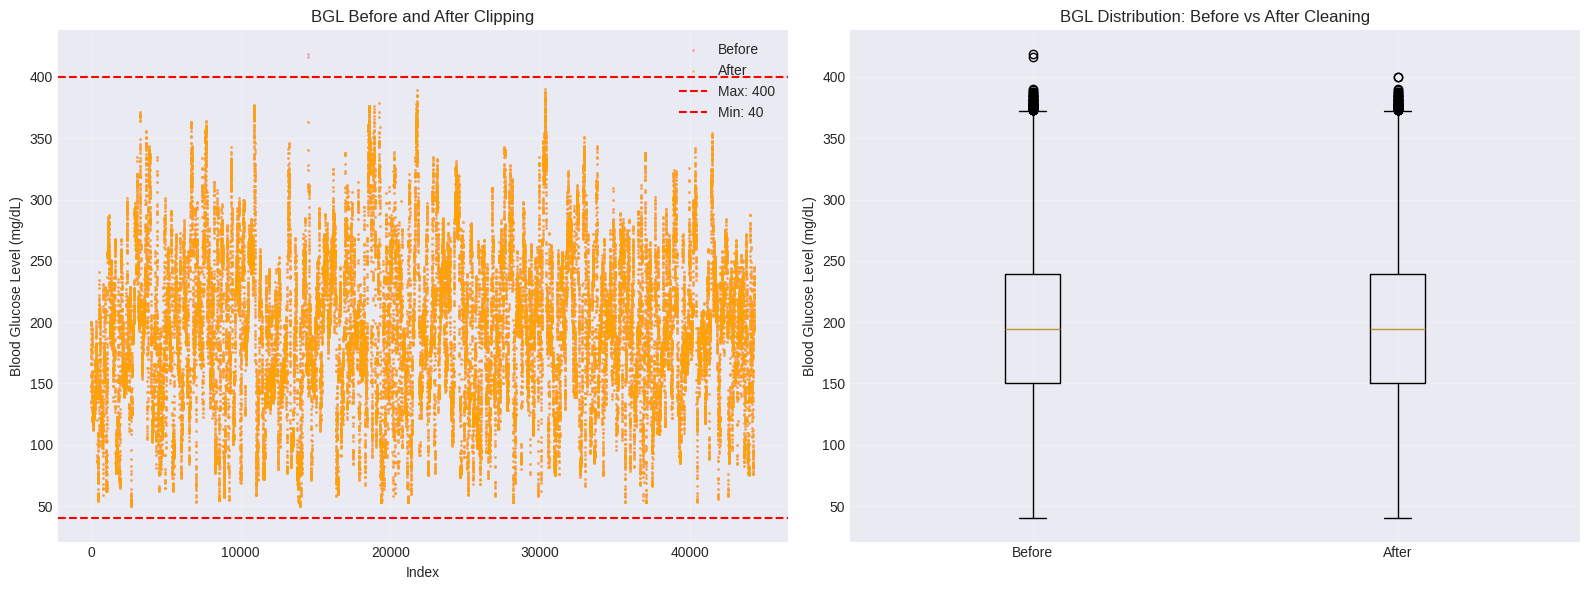

In [37]:
# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before and after comparison
axes[0].scatter(range(len(bgl_before)), bgl_before, alpha=0.5, s=1, label='Before')
axes[0].scatter(range(len(df_clean['bgl'])), df_clean['bgl'], alpha=0.5, s=1, label='After', color='orange')
axes[0].axhline(MEDICAL_MAX, color='r', linestyle='--', label=f'Max: {MEDICAL_MAX}')
axes[0].axhline(MEDICAL_MIN, color='r', linestyle='--', label=f'Min: {MEDICAL_MIN}')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Blood Glucose Level (mg/dL)')
axes[0].set_title('BGL Before and After Clipping')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot comparison
box_data = [bgl_before, df_clean['bgl']]
axes[1].boxplot(box_data, labels=['Before', 'After'])
axes[1].set_ylabel('Blood Glucose Level (mg/dL)')
axes[1].set_title('BGL Distribution: Before vs After Cleaning')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Trend Type Distribution





In [38]:
print("\nEvent Type Distribution:")
event_counts = df_clean['eventType'].value_counts()
print(event_counts)
print(f"\n  Percentage:")
for event, count in event_counts.items():
    print(f"    {event}: {count/len(df_clean)*100:.2f}%")


Event Type Distribution:
eventType
cgm_reading    44319
message            9
Name: count, dtype: int64

  Percentage:
    cgm_reading: 99.98%
    message: 0.02%


In [39]:
print("\nTrend Distribution:")
trend_counts = df_clean['trend'].value_counts()
print(trend_counts)
print(f"\n  Percentage:")
for trend, count in trend_counts.items():
    print(f"    {trend}: {count/len(df_clean)*100:.2f}%")



Trend Distribution:
trend
FLAT              34101
NONE               3485
FORTYFIVE_UP       2526
FORTYFIVE_DOWN     2239
SINGLE_UP          1161
SINGLE_DOWN         816
Name: count, dtype: int64

  Percentage:
    FLAT: 76.93%
    NONE: 7.86%
    FORTYFIVE_UP: 5.70%
    FORTYFIVE_DOWN: 5.05%
    SINGLE_UP: 2.62%
    SINGLE_DOWN: 1.84%


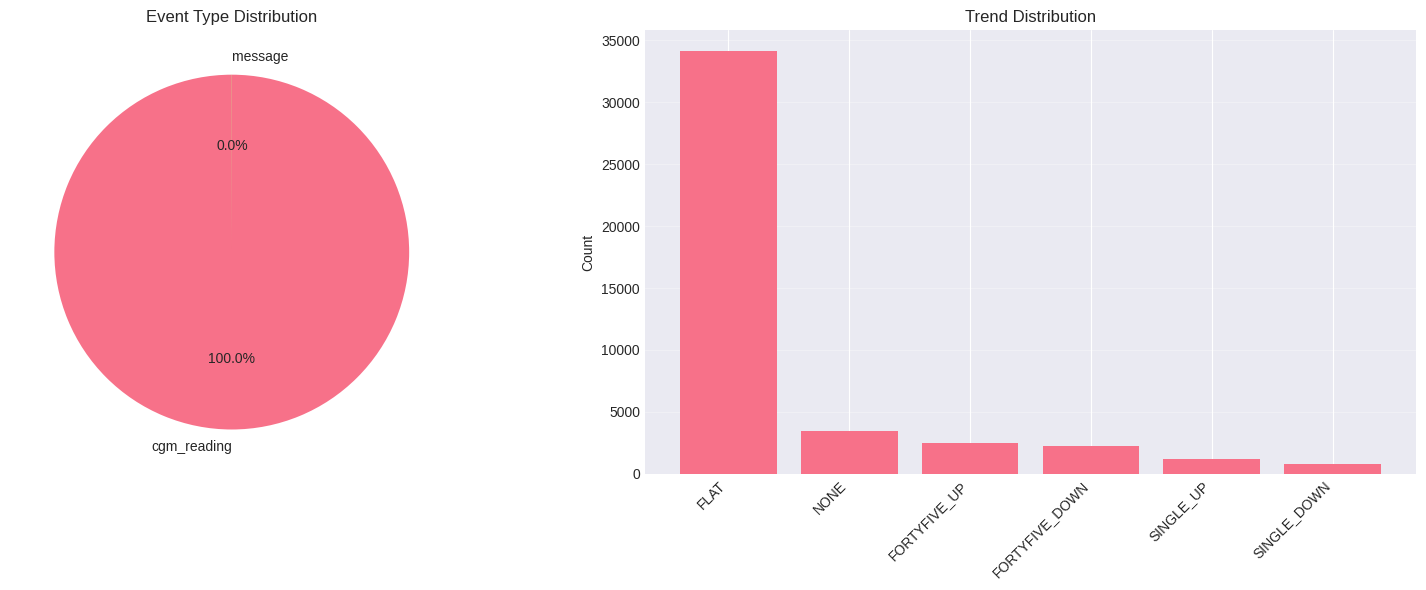

In [40]:
# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Event type pie chart
axes[0].pie(event_counts.values, labels=event_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Event Type Distribution')

# Trend bar chart
axes[1].bar(range(len(trend_counts)), trend_counts.values)
axes[1].set_xticks(range(len(trend_counts)))
axes[1].set_xticklabels(trend_counts.index, rotation=45, ha='right')
axes[1].set_ylabel('Count')
axes[1].set_title('Trend Distribution')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Time Series Preparation

In [41]:
#date indexing
df_ts = df_clean.set_index('date').sort_index()


In [42]:
# Keep only BGL for time series analysis
df_ts = df_ts[['bgl']].copy()

print(f"\nTime Series Info:")
print(f"  Start: {df_ts.index.min()}")
print(f"  End: {df_ts.index.max()}")
print(f"  Total records: {len(df_ts):,}")
print(f"  Time span: {(df_ts.index.max() - df_ts.index.min()).days} days")



Time Series Info:
  Start: 2025-09-07 20:37:57+00:00
  End: 2025-12-06 21:34:19+00:00
  Total records: 44,328
  Time span: 90 days


In [43]:
time_diffs = df_ts.index.to_series().diff()
median_interval = time_diffs.median()
mean_interval = time_diffs.mean()

print(f"\nTime Intervals:")
print(f"  Median: {median_interval}")
print(f"  Mean: {mean_interval}")


Time Intervals:
  Median: 0 days 00:02:01
  Mean: 0 days 00:02:55.499853362


In [44]:
print(f"\nResampling to 5-minute intervals...")
df_resampled = df_ts['bgl'].resample('5min').mean()


Resampling to 5-minute intervals...


### Checking missing values after resampling

In [45]:
print(f"  Records after resampling: {len(df_resampled):,}")
print(f"  Missing values: {df_resampled.isna().sum():,} ({df_resampled.isna().sum()/len(df_resampled)*100:.2f}%)")


  Records after resampling: 25,932
  Missing values: 6,306 (24.32%)


### Handling missing values with interpolation

In [46]:
print(f"\nInterpolating missing values...")
df_resampled = df_resampled.interpolate(method='linear', limit_direction='both', limit=12)  # Max 1 hour gap



Interpolating missing values...


In [47]:
df_resampled = df_resampled.ffill().bfill()

print(f"  Missing values after interpolation: {df_resampled.isna().sum()}")


  Missing values after interpolation: 0


In [48]:
df_ts_clean = pd.DataFrame({'bgl': df_resampled})
print(f"  Final shape: {df_ts_clean.shape}")


  Final shape: (25932, 1)


## Time Series Visualization

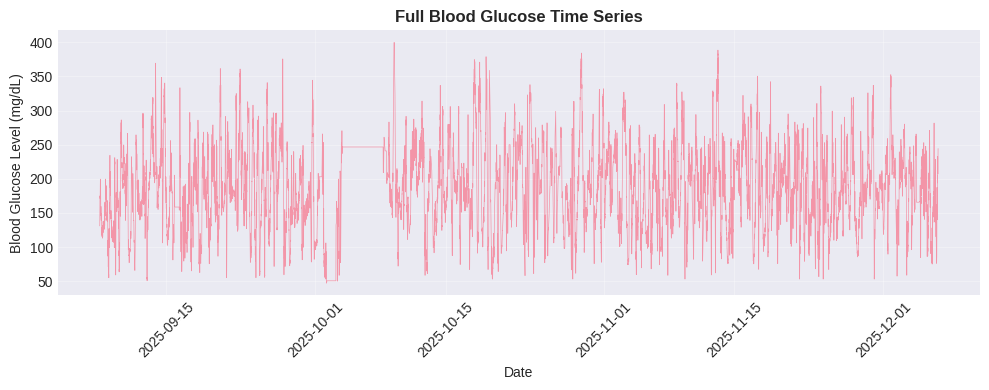

In [49]:
# Full time series
plt.figure(figsize=(10, 4))
plt.plot(df_ts_clean.index, df_ts_clean['bgl'], linewidth=0.5, alpha=0.7)
plt.title('Full Blood Glucose Time Series', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Blood Glucose Level (mg/dL)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


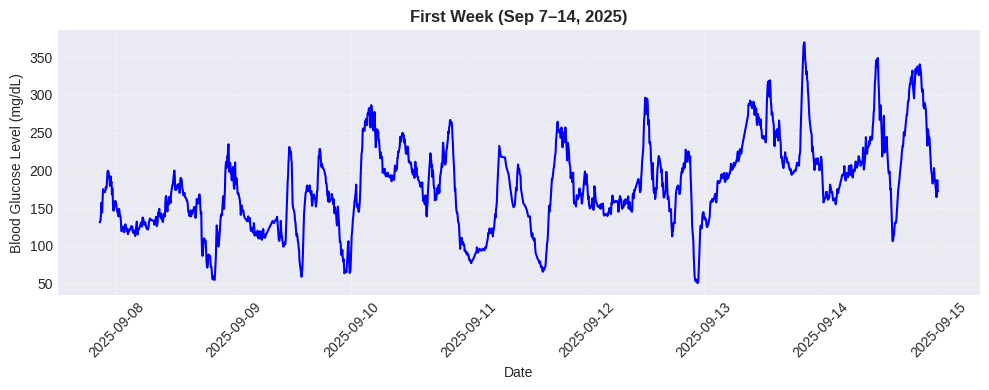

In [50]:
#  First week
first_week_data = df_ts_clean['2025-09-07':'2025-09-14']

plt.figure(figsize=(10, 4))
plt.plot(first_week_data.index, first_week_data['bgl'],color='blue', linewidth=1.5)
plt.title('First Week (Sep 7–14, 2025)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Blood Glucose Level (mg/dL)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


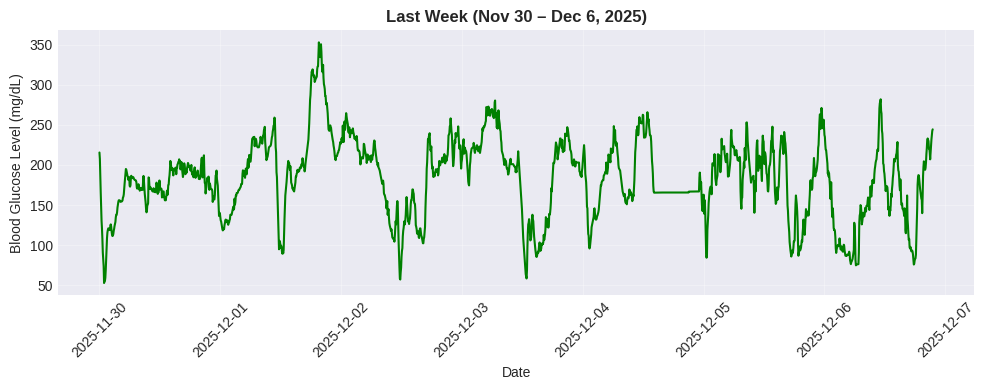

In [51]:
# Last week
last_week_data = df_ts_clean['2025-11-30':'2025-12-06']

plt.figure(figsize=(10, 4))
plt.plot(last_week_data.index, last_week_data['bgl'], color='green', linewidth=1.5)
plt.title('Last Week (Nov 30 – Dec 6, 2025)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Blood Glucose Level (mg/dL)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


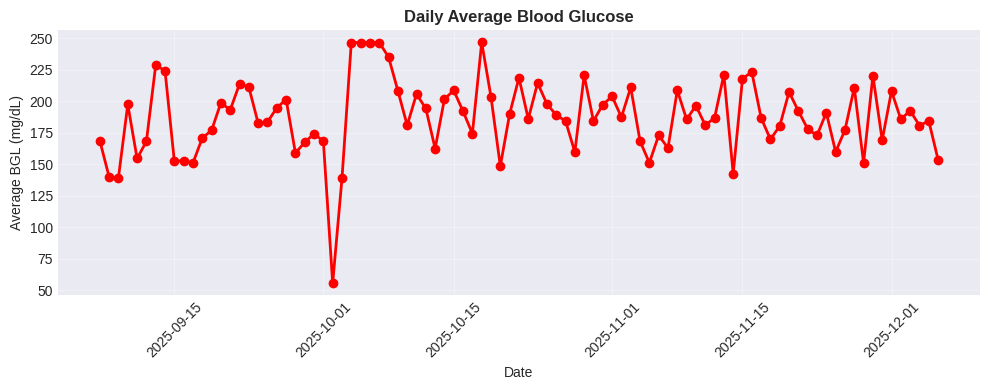

In [52]:
# Daily average
daily_avg = df_ts_clean['bgl'].resample('D').mean()

plt.figure(figsize=(10, 4))
plt.plot(daily_avg.index, daily_avg.values, linewidth=2,color='red', marker='o')
plt.title('Daily Average Blood Glucose', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average BGL (mg/dL)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


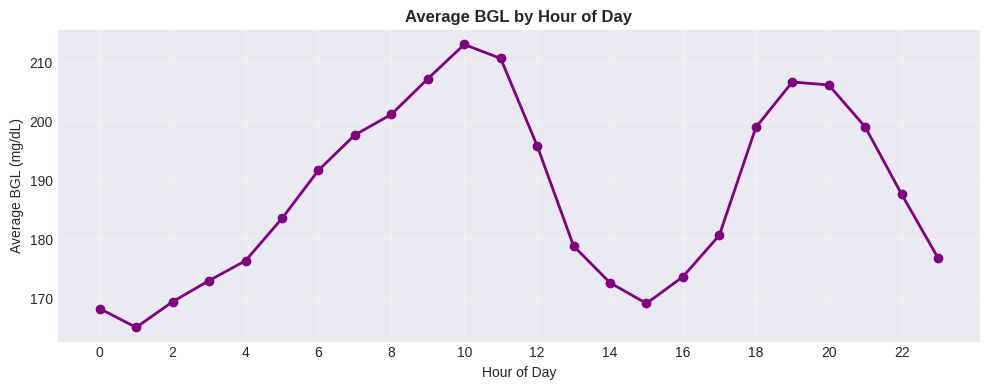

In [53]:
#  Hourly pattern
hourly_avg = df_ts_clean.groupby(df_ts_clean.index.hour)['bgl'].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_avg.index, hourly_avg.values, linewidth=2,color='purple', marker='o')
plt.title('Average BGL by Hour of Day', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Average BGL (mg/dL)')
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


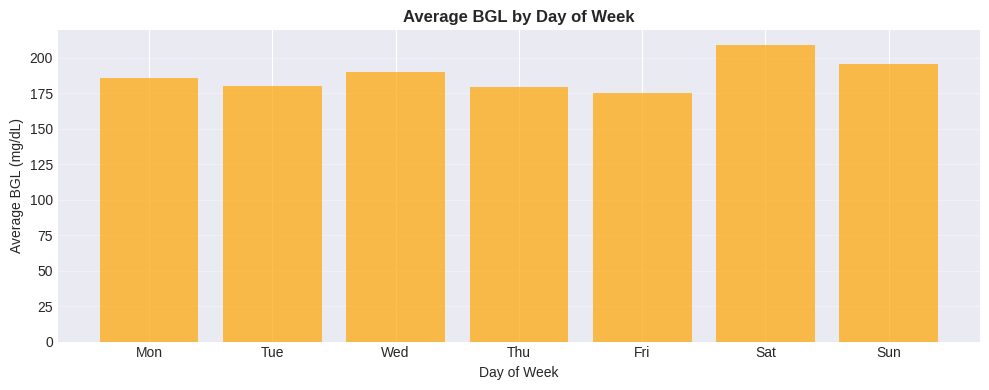

In [54]:
# Weekly pattern
weekly_avg = df_ts_clean.groupby(df_ts_clean.index.dayofweek)['bgl'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10, 4))
plt.bar(day_names, weekly_avg.values, color= 'orange',alpha=0.7)
plt.title('Average BGL by Day of Week', fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average BGL (mg/dL)')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Stationarity Check

In [55]:
def adf_test(timeseries, title="Time Series"):
    """Perform Augmented Dickey-Fuller test for stationarity"""
    result = adfuller(timeseries.dropna(), autolag='AIC')

    print(f"\n{title}:")
    print(f"  ADF Statistic: {result[0]:.6f}")
    print(f"  p-value: {result[1]:.6f}")
    print(f"  Critical Values:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.6f}")

    if result[1] <= 0.05:
        print(f" Result: Stationary (p-value <= 0.05)")
        return True
    else:
        print(f" Result: Non-stationary (p-value > 0.05)")
        return False

In [56]:
is_stationary = adf_test(df_ts_clean['bgl'], "Original BGL Series")

# If not stationary, try differencing
if not is_stationary:
    print("\n" + "-" * 80)
    print("Testing first difference...")
    df_ts_clean['bgl_diff'] = df_ts_clean['bgl'].diff()
    is_stationary_diff = adf_test(df_ts_clean['bgl_diff'].dropna(), "First Difference")


Original BGL Series:
  ADF Statistic: -18.284140
  p-value: 0.000000
  Critical Values:
    1%: -3.430602
    5%: -2.861652
    10%: -2.566829
 Result: Stationary (p-value <= 0.05)


## Time Series Decomposition


Decomposing time series (using first 5000 points)...
  Period: 288 (24 hours in 5-minute intervals)


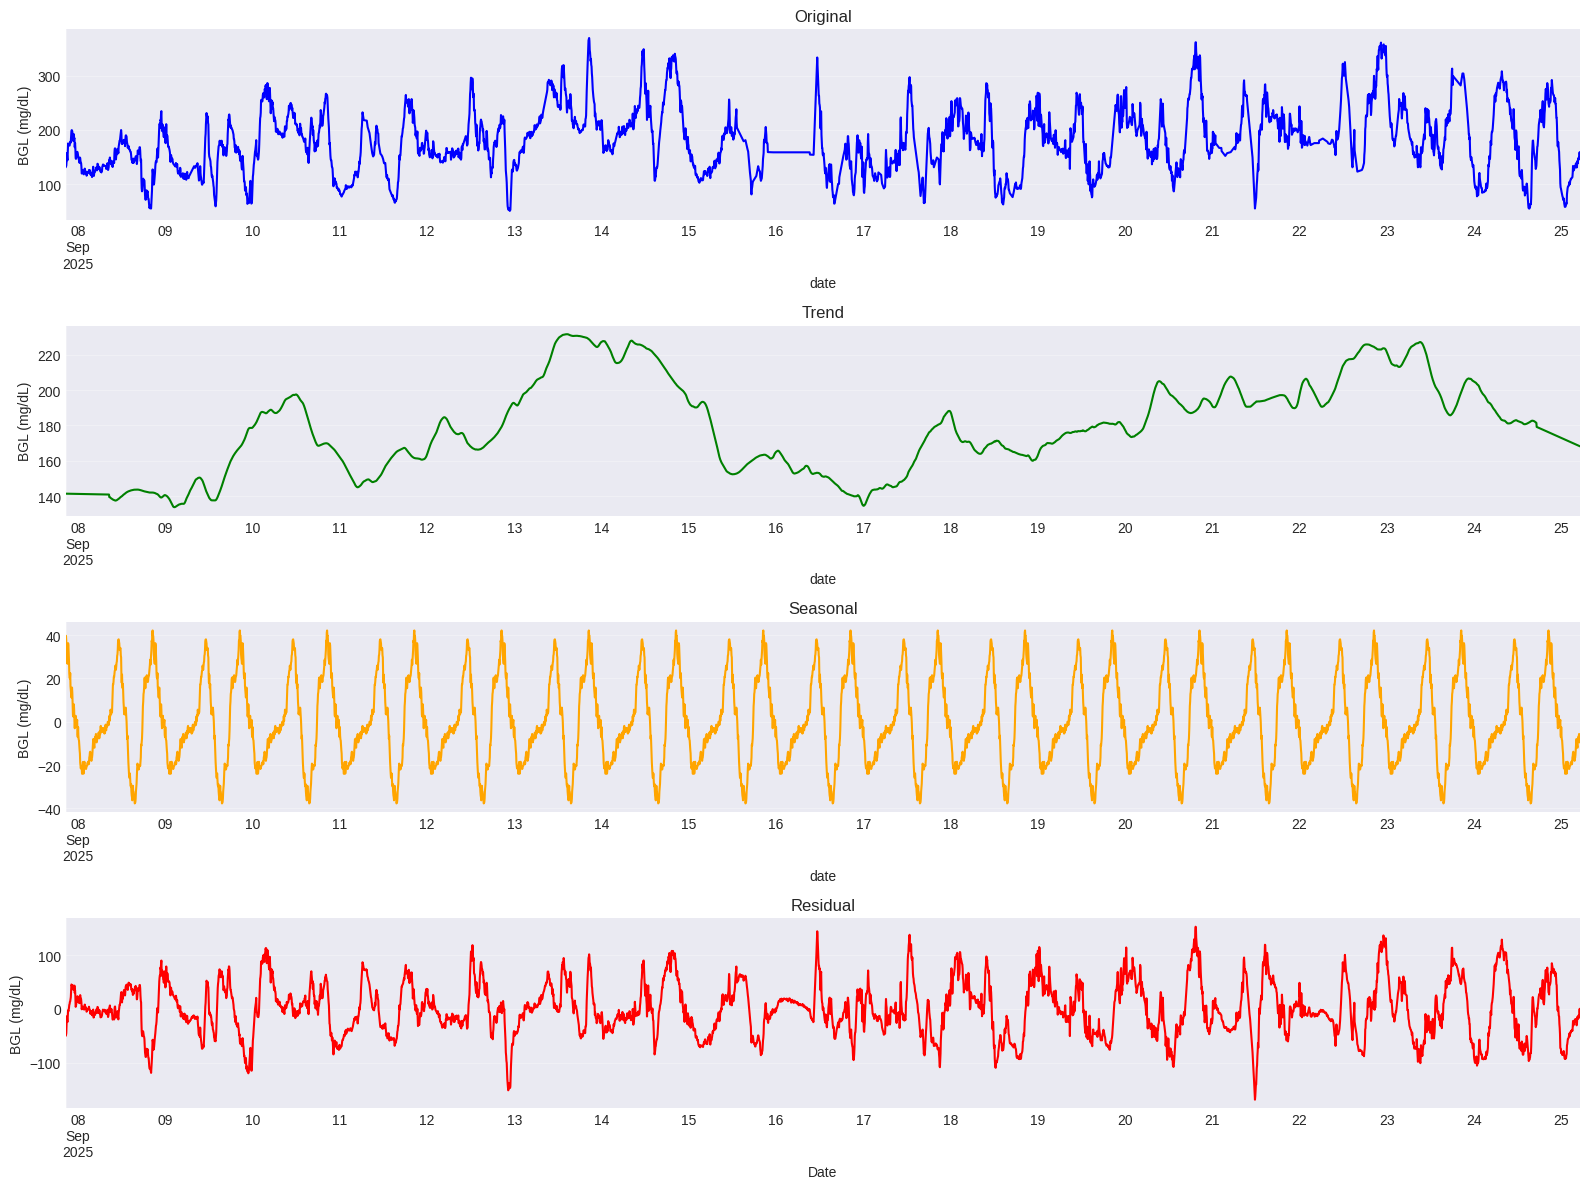

 Decomposition completed successfully!


In [57]:
period = 288

decomp_data = df_ts_clean['bgl'].iloc[:5000]

print(f"\nDecomposing time series (using first {len(decomp_data)} points)...")
print(f"  Period: {period} (24 hours in 5-minute intervals)")

try:
    decomposition = seasonal_decompose(decomp_data, model='additive', period=period, extrapolate_trend='freq')

    # Plot decomposition
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))

    decomposition.observed.plot(ax=axes[0], title='Original', color='blue')
    axes[0].set_ylabel('BGL (mg/dL)')
    axes[0].grid(True, alpha=0.3)

    decomposition.trend.plot(ax=axes[1], title='Trend', color='green')
    axes[1].set_ylabel('BGL (mg/dL)')
    axes[1].grid(True, alpha=0.3)

    decomposition.seasonal.plot(ax=axes[2], title='Seasonal', color='orange')
    axes[2].set_ylabel('BGL (mg/dL)')
    axes[2].grid(True, alpha=0.3)

    decomposition.resid.plot(ax=axes[3], title='Residual', color='red')
    axes[3].set_ylabel('BGL (mg/dL)')
    axes[3].set_xlabel('Date')
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(" Decomposition completed successfully!")

except Exception as e:
    print(f"Warning: Decomposition failed: {e}")
    print("  This might be due to insufficient data or period mismatch")



## Autocorrelation Analysis

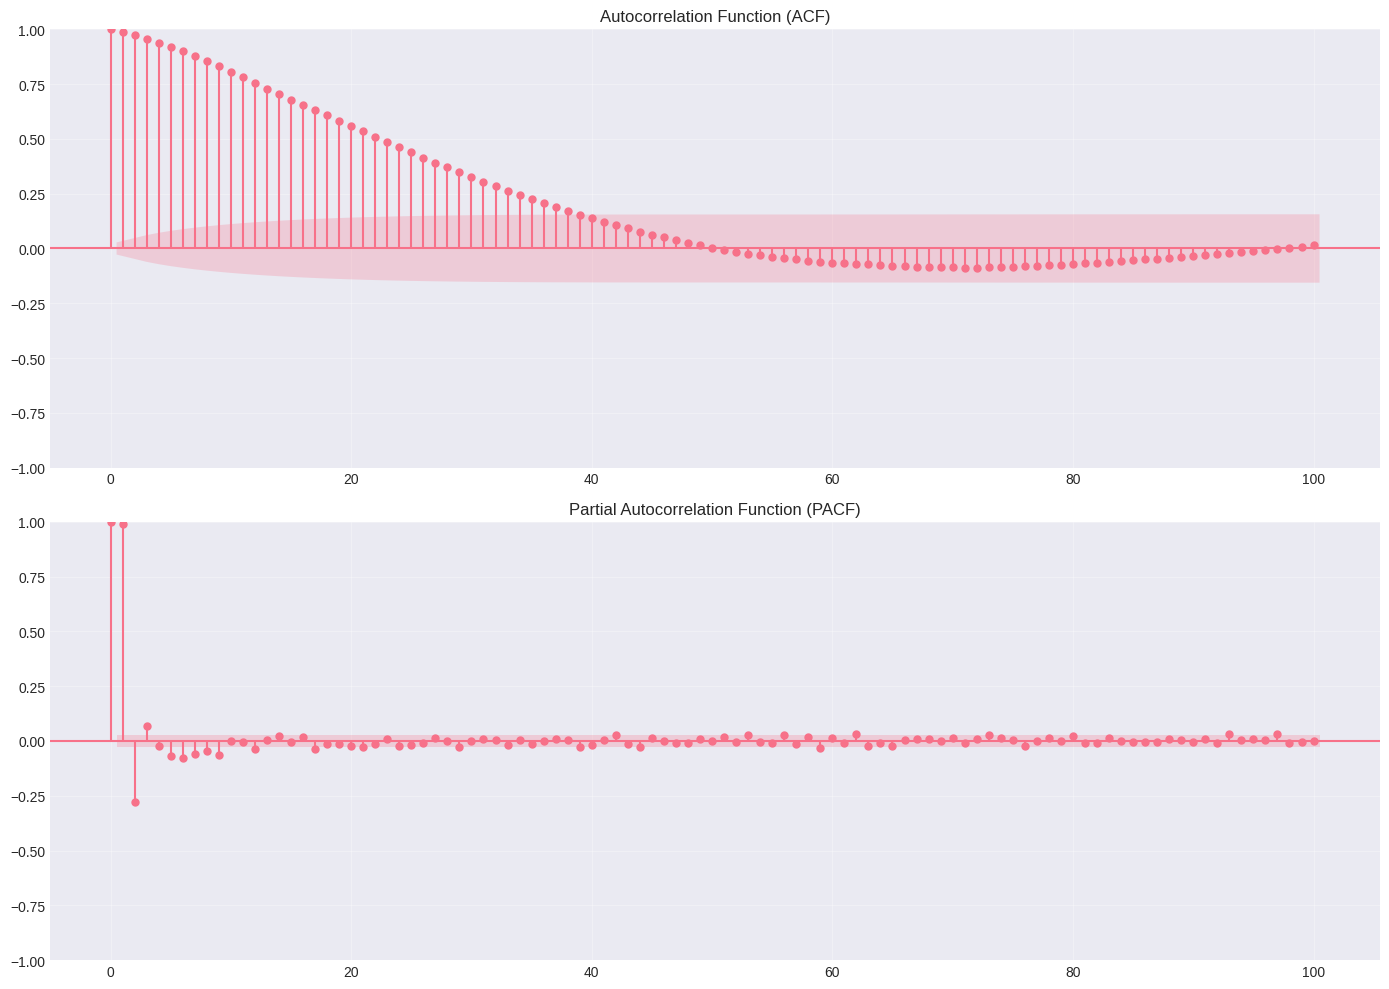

In [58]:
acf_data = df_ts_clean['bgl'].iloc[:5000]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ACF Plot
plot_acf(acf_data.dropna(), lags=100, ax=axes[0], title='Autocorrelation Function (ACF)')
axes[0].grid(True, alpha=0.3)

# PACF Plot
plot_pacf(acf_data.dropna(), lags=100, ax=axes[1], title='Partial Autocorrelation Function (PACF)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [59]:
df_export = df_ts_clean.reset_index()
df_export.columns = ['date', 'bgl']

df_export['hour'] = df_export['date'].dt.hour
df_export['day_of_week'] = df_export['date'].dt.dayofweek
df_export['day_name'] = df_export['date'].dt.day_name()
df_export['month'] = df_export['date'].dt.month
df_export['day'] = df_export['date'].dt.day

df_export = df_export[['date', 'bgl', 'hour', 'day_of_week', 'day_name', 'month', 'day']]

print(f"\nPrepared data for export:")
print(f"  Shape: {df_export.shape[0]:,} rows × {df_export.shape[1]} columns")
print(f"  Date range: {df_export['date'].min()} to {df_export['date'].max()}")
print(f"\nFirst few rows:")
print(df_export.head())

output_file = "gluroo_data_cleaned.xlsx"

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        df_export.to_excel(writer, sheet_name='Cleaned_Data', index=False)

        summary_stats = pd.DataFrame({
            'Metric': ['Total Records', 'Date Range Start', 'Date Range End',
                      'Mean BGL', 'Median BGL', 'Std BGL', 'Min BGL', 'Max BGL'],
            'Value': [
                len(df_export),
                str(df_export['date'].min()),
                str(df_export['date'].max()),
                f"{df_export['bgl'].mean():.2f} mg/dL",
                f"{df_export['bgl'].median():.2f} mg/dL",
                f"{df_export['bgl'].std():.2f} mg/dL",
                f"{df_export['bgl'].min():.2f} mg/dL",
                f"{df_export['bgl'].max():.2f} mg/dL"
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary_Statistics', index=False)

        hourly_avg = df_export.groupby('hour')['bgl'].agg(['mean', 'std', 'count']).reset_index()
        hourly_avg.columns = ['Hour', 'Mean_BGL', 'Std_BGL', 'Count']
        hourly_avg.to_excel(writer, sheet_name='Hourly_Averages', index=False)

        daily_avg = df_export.groupby(df_export['date'].dt.date)['bgl'].agg(['mean', 'std', 'count']).reset_index()
        daily_avg.columns = ['Date', 'Mean_BGL', 'Std_BGL', 'Count']
        daily_avg.to_excel(writer, sheet_name='Daily_Averages', index=False)

        if 'future_forecast_extract' in globals():
            forecast_export = future_forecast_extract.reset_index()
            forecast_export.columns = ['date', 'forecast', 'lower_bound', 'upper_bound']
            forecast_export.to_excel(writer, sheet_name='Future_Forecast', index=False)

    print(f"\n Data exported successfully to: {output_file}")
    print(f"  File contains {len(pd.ExcelFile(output_file).sheet_names)} sheets:")
    for sheet in pd.ExcelFile(output_file).sheet_names:
        print(f"    - {sheet}")

except Exception as e:
    print(f"\n Error exporting to Excel: {e}")
    print("  Trying CSV export instead...")
    try:
        csv_file = "gluroo_data_cleaned.csv"
        df_export.to_csv(csv_file, index=False)
        print(f"Data exported to CSV: {csv_file}")
    except Exception as e2:
        print(f"CSV export also failed: {e2}")





Prepared data for export:
  Shape: 25,932 rows × 7 columns
  Date range: 2025-09-07 20:35:00+00:00 to 2025-12-06 21:30:00+00:00

First few rows:
                       date    bgl  hour  day_of_week day_name  month  day
0 2025-09-07 20:35:00+00:00  131.0    20            6   Sunday      9    7
1 2025-09-07 20:40:00+00:00  132.5    20            6   Sunday      9    7
2 2025-09-07 20:45:00+00:00  134.0    20            6   Sunday      9    7
3 2025-09-07 20:50:00+00:00  141.5    20            6   Sunday      9    7
4 2025-09-07 20:55:00+00:00  157.0    20            6   Sunday      9    7

 Error exporting to Excel: Excel does not support datetimes with timezones. Please ensure that datetimes are timezone unaware before writing to Excel.
  Trying CSV export instead...
Data exported to CSV: gluroo_data_cleaned.csv


## Preparing the data for preprocessing

In [60]:
split_point = int(len(df_ts_clean) * 0.8)
train_data = df_ts_clean.iloc[:split_point].copy()
test_data = df_ts_clean.iloc[split_point:].copy()

print(f"\nData Split:")
print(f"  Training set: {len(train_data):,} records ({len(train_data)/len(df_ts_clean)*100:.1f}%)")
print(f"  Test set: {len(test_data):,} records ({len(test_data)/len(df_ts_clean)*100:.1f}%)")
print(f"  Training period: {train_data.index.min()} to {train_data.index.max()}")
print(f"  Test period: {test_data.index.min()} to {test_data.index.max()}")



Data Split:
  Training set: 20,745 records (80.0%)
  Test set: 5,187 records (20.0%)
  Training period: 2025-09-07 20:35:00+00:00 to 2025-11-18 21:15:00+00:00
  Test period: 2025-11-18 21:20:00+00:00 to 2025-12-06 21:30:00+00:00


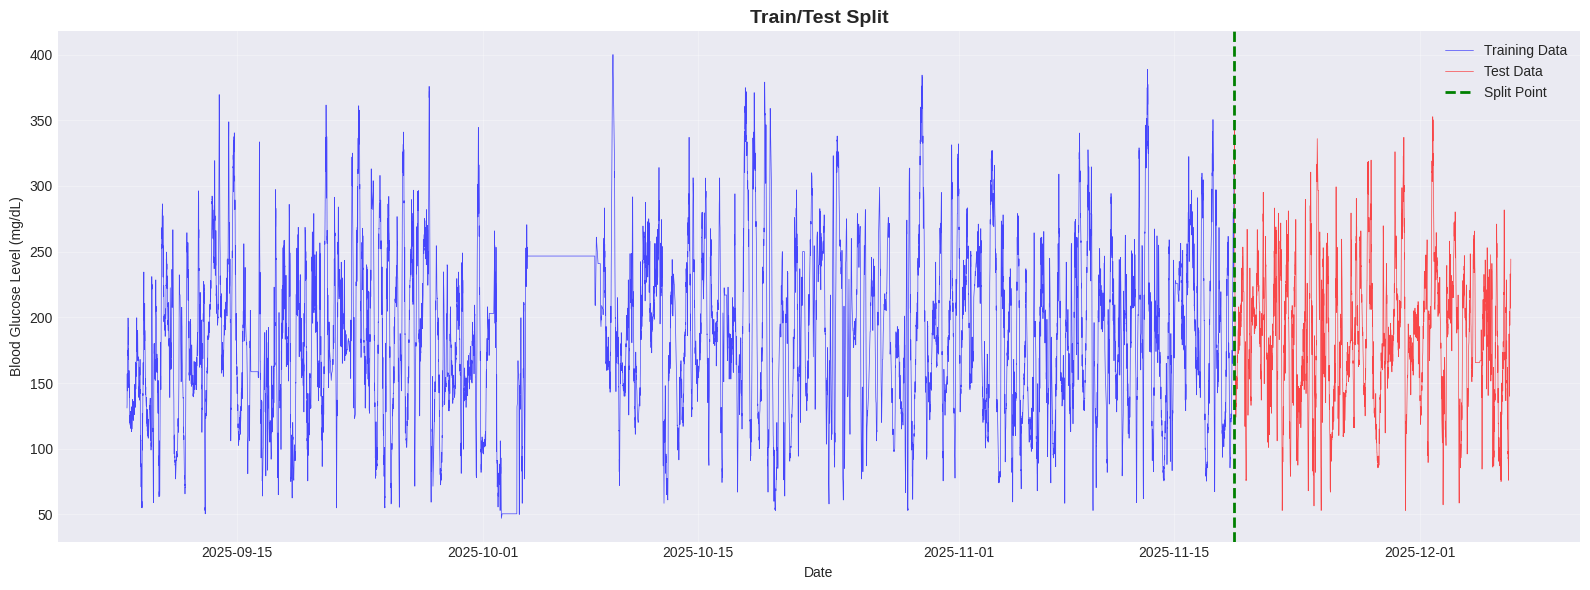

In [61]:
plt.figure(figsize=(16, 6))
plt.plot(train_data.index, train_data['bgl'], label='Training Data', color='blue', alpha=0.7, linewidth=0.5)
plt.plot(test_data.index, test_data['bgl'], label='Test Data', color='red', alpha=0.7, linewidth=0.5)
plt.axvline(train_data.index.max(), color='green', linestyle='--', linewidth=2, label='Split Point')
plt.title('Train/Test Split', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Blood Glucose Level (mg/dL)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [62]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data[['bgl']])
test_scaled  = scaler.transform(test_data[['bgl']])


In [63]:
import numpy as np

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)


In [64]:
WINDOW_SIZE = 24  # 2 hours if data is 5 min

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test, y_test   = create_sequences(test_scaled, WINDOW_SIZE)


In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

print("FORECASTING METHOD 1: LSTM")

lstm_model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Forecast
lstm_pred_scaled = lstm_model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_inv = scaler.inverse_transform(y_test)

# Metrics
lstm_mae = mean_absolute_error(y_test_inv, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_inv, lstm_pred))
lstm_mape = np.mean(np.abs((y_test_inv - lstm_pred) / y_test_inv)) * 100

print(f"LSTM MAE: {lstm_mae:.2f}")
print(f"LSTM RMSE: {lstm_rmse:.2f}")
print(f"LSTM MAPE: {lstm_mape:.2f}%")

FORECASTING METHOD 1: LSTM
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0112 - val_loss: 0.0018
Epoch 2/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 3/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 9.2301e-04 - val_loss: 8.4607e-04
Epoch 4/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 7.6330e-04 - val_loss: 7.4943e-04
Epoch 5/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 6.2906e-04 - val_loss: 6.8949e-04
Epoch 6/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 5.6493e-04 - val_loss: 6.1112e-04
Epoch 7/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5.2804e-04 - val_loss: 5.2602e-04
Epoch 8/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 4.6648e-04 - val_loss: 5.3708e-04
Epoch 9/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 4.4634e-04 - val_loss: 4.6345e-04
Epoch 10/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 4.1911e-04 - val_loss: 4.5775e-04
Epoch 11/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 4.0714e-04 - va

In [66]:
from tensorflow.keras.layers import GRU

print("GRU")

gru_model = Sequential([
    GRU(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')

history_gru = gru_model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

gru_pred_scaled = gru_model.predict(X_test)
gru_pred = scaler.inverse_transform(gru_pred_scaled)

gru_mae = mean_absolute_error(y_test_inv, gru_pred)
gru_rmse = np.sqrt(mean_squared_error(y_test_inv, gru_pred))
gru_mape = np.mean(np.abs((y_test_inv - gru_pred) / y_test_inv)) * 100

print(f"GRU MAE: {gru_mae:.2f}")
print(f"GRU RMSE: {gru_rmse:.2f}")
print(f"GRU MAPE: {gru_mape:.2f}%")

GRU
Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


292/292 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0132 - val_loss: 0.0010
Epoch 2/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 7.9199e-04 - val_loss: 7.0927e-04
Epoch 3/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 6.0594e-04 - val_loss: 6.2641e-04
Epoch 4/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5.4360e-04 - val_loss: 5.8536e-04
Epoch 5/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 5.0323e-04 - val_loss: 5.4520e-04
Epoch 6/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 4.5846e-04 - val_loss: 5.0791e-04
Epoch 7/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 4.3425e-04 - val_loss: 4.8604e-04
Epoch 8/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 4.2285e-04 - val_loss: 5.4142e-04
Epoch 9/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 4.1228e-04 - val_loss: 4.6023e-04
Epoch 10/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 4.0805e-04 - val_loss: 4.5371e-04
Epoch 11/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 3.8892

In [67]:
!pip install hmmlearn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.1 MB/s eta 0:00:00


In [68]:
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


best_bic = np.inf
best_n = 0
bic_list = []

for n in range(2, 7):  # test 2 to 6 states
    model = GaussianHMM(n_components=n, covariance_type='diag', n_iter=600, random_state=42)
    model.fit(train_scaled)
    bic = model.bic(train_scaled)
    bic_list.append((n, bic))
    if bic < best_bic:
        best_bic = bic
        best_n = n

print(f"Optimal number of states by BIC: {best_n}")


hmm_model = GaussianHMM(n_components=best_n, covariance_type='diag', n_iter=600, random_state=42)
hmm_model.fit(train_scaled)


state_probs = hmm_model.predict_proba(test_scaled)  # shape: (n_samples, n_states)
hmm_means = hmm_model.means_.flatten()             # mean of each state


hmm_pred_weighted = (state_probs * hmm_means).sum(axis=1)  # weighted sum across states


window = 3
hmm_pred_smooth = np.convolve(hmm_pred_weighted, np.ones(window)/window, mode='same')


hmm_pred_final = scaler.inverse_transform(hmm_pred_smooth.reshape(-1, 1))


test_actual = test_data['bgl'].iloc[:len(hmm_pred_final)]

hmm_mae = mean_absolute_error(test_actual, hmm_pred_final)
hmm_rmse = np.sqrt(mean_squared_error(test_actual, hmm_pred_final))
hmm_mape = np.mean(np.abs((test_actual - hmm_pred_final.flatten()) / test_actual)) * 100

print(f"HMM MAE: {hmm_mae:.2f}")
print(f"HMM RMSE: {hmm_rmse:.2f}")
print(f"HMM MAPE: {hmm_mape:.2f}%")


Optimal number of states by BIC: 6
HMM MAE: 9.83
HMM RMSE: 13.65
HMM MAPE: 5.94%


In [69]:

lstm_accuracy = 100 - lstm_mape
gru_accuracy  = 100 - gru_mape
hmm_accuracy  = 100 - hmm_mape

print(f"LSTM Accuracy: {lstm_accuracy:.2f}%")
print(f"GRU Accuracy: {gru_accuracy:.2f}%")
print(f"HMM Accuracy: {hmm_accuracy:.2f}%")


LSTM Accuracy: 96.86%
GRU Accuracy: 96.88%
HMM Accuracy: 94.06%


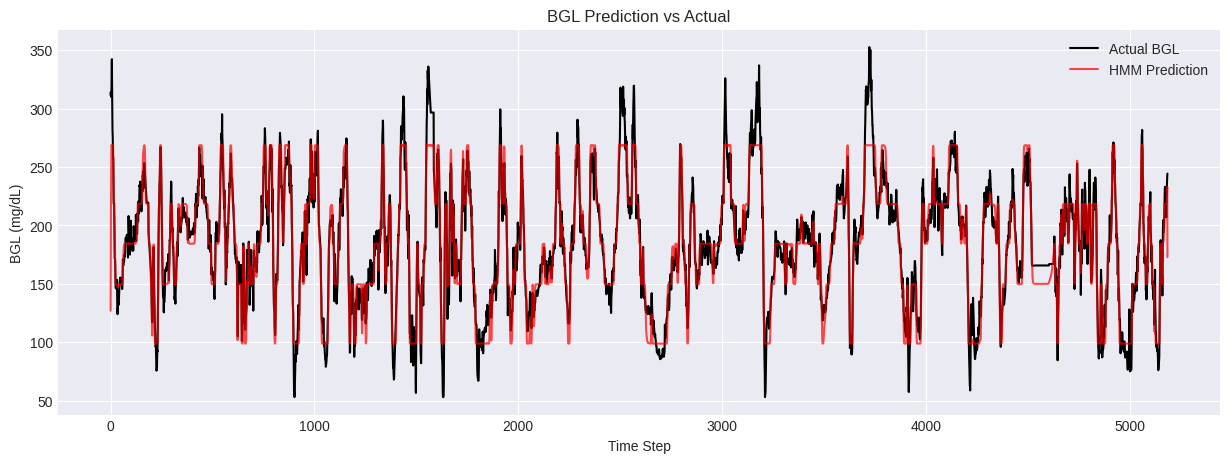

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(test_data['bgl'].values[:len(hmm_pred_final)], label='Actual BGL', color='black')
plt.plot(hmm_pred_final, label='HMM Prediction', color='red', alpha=0.7)
# If you have other models, plot them too:
# plt.plot(model2_pred, label='Random Forest', color='blue', alpha=0.7)
# plt.plot(model3_pred, label='ARIMA', color='green', alpha=0.7)
plt.title("BGL Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("BGL (mg/dL)")
plt.legend()
plt.show()


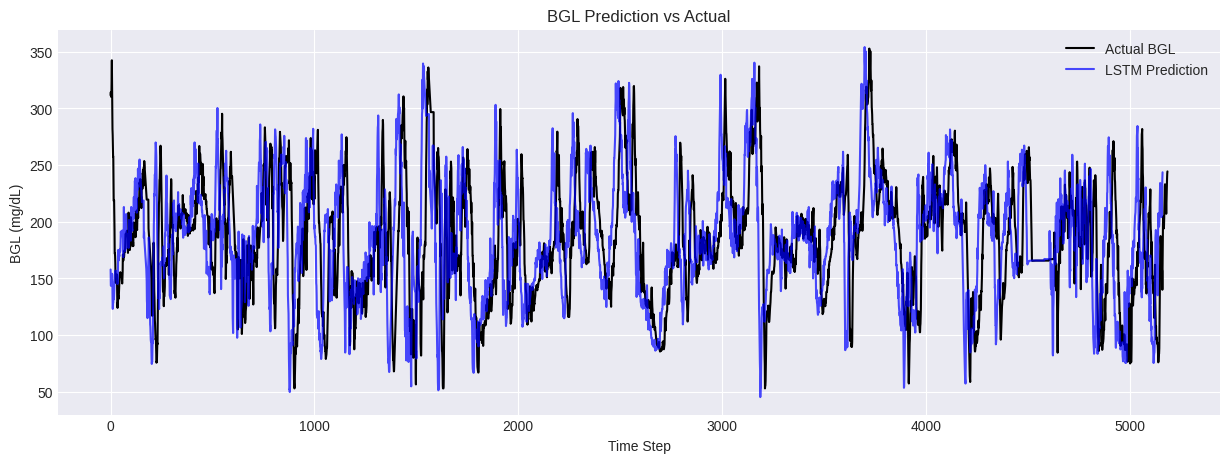

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(test_data['bgl'].values[:len(hmm_pred_final)], label='Actual BGL', color='black')
plt.plot(lstm_pred.flatten(), label='LSTM Prediction', color='blue', alpha=0.7)
# If you have other models, plot them too:
# plt.plot(model2_pred, label='Random Forest', color='blue', alpha=0.7)
# plt.plot(model3_pred, label='ARIMA', color='green', alpha=0.7)
plt.title("BGL Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("BGL (mg/dL)")
plt.legend()
plt.show()


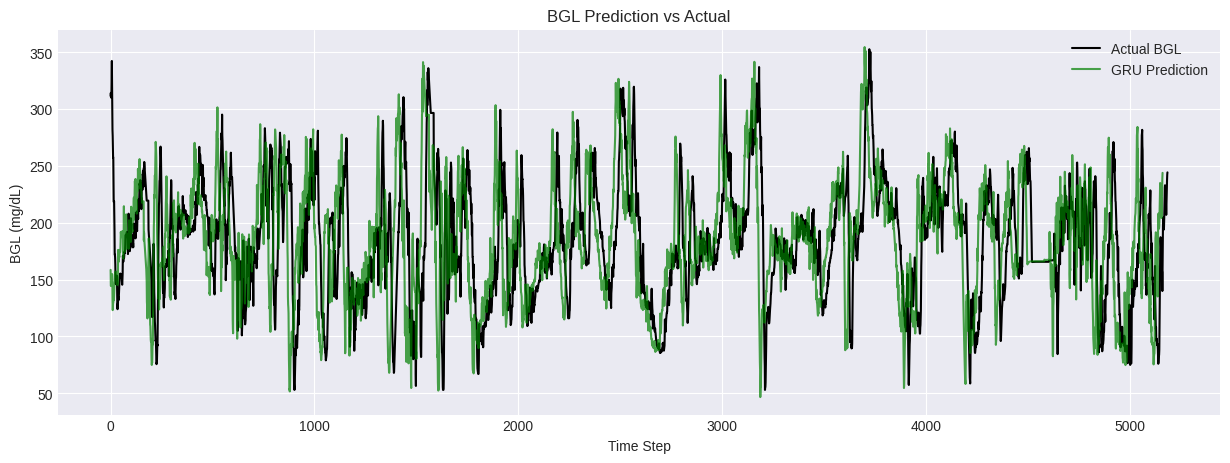

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(test_data['bgl'].values[:len(hmm_pred_final)], label='Actual BGL', color='black')
plt.plot(gru_pred.flatten(), label='GRU Prediction', color='green', alpha=0.7)
# If you have other models, plot them too:
# plt.plot(model2_pred, label='Random Forest', color='blue', alpha=0.7)
# plt.plot(model3_pred, label='ARIMA', color='green', alpha=0.7)
plt.title("BGL Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("BGL (mg/dL)")
plt.legend()
plt.show()


In [73]:
def sanity_check(name, y_true, y_pred):
    print(f"\n{name} Sanity Check")
    print("Actual min/max:", y_true.min(), y_true.max())
    print("Pred min/max:", y_pred.min(), y_pred.max())
    print("Mean Actual:", y_true.mean())
    print("Mean Pred:", y_pred.mean())


In [74]:
sanity_check("HMM", y_test_inv.flatten(), hmm_pred_final.flatten())
sanity_check("LSTM", y_test_inv.flatten(), lstm_pred.flatten())
sanity_check("GRU", y_test_inv.flatten(), gru_pred.flatten())



HMM Sanity Check
Actual min/max: 53.0 352.6666666666667
Pred min/max: 98.80743437985006 268.8946468343996
Mean Actual: 184.31022729856866
Mean Pred: 183.57767841192776

LSTM Sanity Check
Actual min/max: 53.0 352.6666666666667
Pred min/max: 45.343964 353.9771
Mean Actual: 184.31022729856866
Mean Pred: 184.10832

GRU Sanity Check
Actual min/max: 53.0 352.6666666666667
Pred min/max: 46.688957 354.55164
Mean Actual: 184.31022729856866
Mean Pred: 184.4568


In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{name} TEST RESULTS")
    print(f"MAE  = {mae:.2f}")
    print(f"RMSE = {rmse:.2f}")
    print(f"MAPE = {mape:.2f}%")

    return mae, rmse, mape


In [76]:
evaluate_model("HMM", test_actual.values, hmm_pred_final.flatten())
evaluate_model("LSTM", y_test_inv.flatten(), lstm_pred.flatten())
evaluate_model("GRU",  y_test_inv.flatten(), gru_pred.flatten())



HMM TEST RESULTS
MAE  = 9.83
RMSE = 13.65
MAPE = 5.94%

LSTM TEST RESULTS
MAE  = 5.41
RMSE = 7.81
MAPE = 3.14%

GRU TEST RESULTS
MAE  = 5.38
RMSE = 7.78
MAPE = 3.12%


(5.382577730693664,
 np.float64(7.784946971487014),
 np.float64(3.1236948992645965))

In [77]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    # print(f"{name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}") # Commented out to avoid redundant printing if already printed by evaluate_model
    return rmse, mae

# Assuming lstm_model, gru_model, hmm_model, X_train, y_train, X_test, y_test, train_scaled, test_scaled are already defined and populated.

# LSTM Predictions and Metrics
print("LSTM RESULTS")
lstm_train_pred = lstm_model.predict(X_train).flatten()
lstm_test_pred  = lstm_model.predict(X_test).flatten()
lstm_train_rmse, lstm_train_mae = evaluate(y_train.flatten(), lstm_train_pred, "LSTM Train")
lstm_test_rmse, lstm_test_mae   = evaluate(y_test.flatten(), lstm_test_pred, "LSTM Test")

# GRU Predictions and Metrics
print("\nGRU RESULTS")
gru_train_pred = gru_model.predict(X_train).flatten()
gru_test_pred  = gru_model.predict(X_test).flatten()
gru_train_rmse, gru_train_mae = evaluate(y_train.flatten(), gru_train_pred, "GRU Train")
gru_test_rmse, gru_test_mae   = evaluate(y_test.flatten(), gru_test_pred, "GRU Test")

# HMM Predictions and Metrics
print("\nHMM RESULTS")
hmm_train_states = hmm_model.predict(train_scaled)
hmm_test_states  = hmm_model.predict(test_scaled)
hmm_means = hmm_model.means_.flatten()
hmm_train_pred = np.array([hmm_means[s] for s in hmm_train_states])
hmm_test_pred  = np.array([hmm_means[s] for s in hmm_test_states])

hmm_train_rmse, hmm_train_mae = evaluate(train_scaled.flatten(), hmm_train_pred, "HMM Train")
hmm_test_rmse, hmm_test_mae   = evaluate(test_scaled.flatten(), hmm_test_pred, "HMM Test")

results = pd.DataFrame({
    "Model": ["LSTM", "GRU", "HMM"],
    "Train RMSE": [lstm_train_rmse, gru_train_rmse, hmm_train_rmse],
    "Test RMSE":  [lstm_test_rmse,  gru_test_rmse,  hmm_test_rmse],
    "Train MAE":  [lstm_train_mae,  gru_train_mae,  hmm_train_mae],
    "Test MAE":   [lstm_test_mae,   gru_test_mae,   hmm_test_mae]
})

print("\nComparison of Model Performance:")
print(results)
results

LSTM RESULTS
648/648 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

GRU RESULTS
648/648 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

HMM RESULTS

Comparison of Model Performance:
  Model  Train RMSE  Test RMSE  Train MAE  Test MAE
0  LSTM    0.019599   0.022126   0.012827  0.015328
1   GRU    0.019606   0.022054   0.012735  0.015248
2   HMM    0.057961   0.044671   0.042552  0.034989


,Model,Train RMSE,Test RMSE,Train MAE,Test MAE
0,LSTM,0.019599,0.022126,0.012827,0.015328
1,GRU,0.019606,0.022054,0.012735,0.015248
2,HMM,0.057961,0.044671,0.042552,0.034989


In [78]:
print("Aligning prediction and actual arrays for ensemble...")

# Ensure all prediction arrays are 1D before finding minimum length
# This step also handles potential discrepancies in how they are stored (e.g., (N,1) vs (N,))
lstm_pred_flat = lstm_pred.flatten()
gru_pred_flat = gru_pred.flatten()
hmm_pred_final_flat = hmm_pred_final.flatten()

# Determine the minimum length among the predictions and actuals
min_len = min(len(lstm_pred_flat), len(gru_pred_flat), len(hmm_pred_final_flat), len(y_test_inv.flatten()), len(test_actual))

# Truncate all arrays to the minimum length
lstm_pred_aligned = lstm_pred_flat[:min_len]
gru_pred_aligned = gru_pred_flat[:min_len]
hmm_pred_aligned = hmm_pred_final_flat[:min_len]

# Truncate actual values as well. Use y_test_inv as the common actuals.
y_test_inv_aligned = y_test_inv.flatten()[:min_len]

print(f"All arrays aligned to a length of {min_len} samples.")
print(f"  LSTM Predictions shape: {lstm_pred_aligned.shape}")
print(f"  GRU Predictions shape: {gru_pred_aligned.shape}")
print(f"  HMM Predictions shape: {hmm_pred_aligned.shape}")
print(f"  Actual values shape: {y_test_inv_aligned.shape}")

Aligning prediction and actual arrays for ensemble...
All arrays aligned to a length of 5163 samples.
  LSTM Predictions shape: (5163,)
  GRU Predictions shape: (5163,)
  HMM Predictions shape: (5163,)
  Actual values shape: (5163,)


In [79]:
lstm_hmm_ensemble_pred = (lstm_pred_aligned + hmm_pred_aligned) / 2

print("Ensemble Prediction created by averaging LSTM and HMM predictions.")

# Evaluate the ensemble model
evaluate_model("LSTM-HMM Ensemble", y_test_inv_aligned, lstm_hmm_ensemble_pred)

Ensemble Prediction created by averaging LSTM and HMM predictions.

LSTM-HMM Ensemble TEST RESULTS
MAE  = 22.86
RMSE = 29.54
MAPE = 14.17%


(22.862010860403146,
 np.float64(29.544160033310003),
 np.float64(14.1681748116461))

In [80]:
lstm_gru_ensemble_pred = (lstm_pred_aligned + gru_pred_aligned) / 2

print("Ensemble Prediction created by averaging LSTM and GRU predictions.")

# Evaluate the ensemble model
evaluate_model("LSTM-GRU Ensemble", y_test_inv_aligned, lstm_gru_ensemble_pred)

Ensemble Prediction created by averaging LSTM and GRU predictions.

LSTM-GRU Ensemble TEST RESULTS
MAE  = 5.39
RMSE = 7.79
MAPE = 3.13%


(5.389921837346583,
 np.float64(7.789900690254986),
 np.float64(3.126999937503135))

In [81]:
hmm_gru_ensemble_pred = (hmm_pred_aligned + gru_pred_aligned) / 2

print("Ensemble Prediction created by averaging HMM and GRU predictions.")

# Evaluate the ensemble model
evaluate_model("HMM-GRU Ensemble", y_test_inv_aligned, hmm_gru_ensemble_pred)

Ensemble Prediction created by averaging HMM and GRU predictions.

HMM-GRU Ensemble TEST RESULTS
MAE  = 22.86
RMSE = 29.57
MAPE = 14.19%


(22.86308317725574,
 np.float64(29.566627452701294),
 np.float64(14.188399048868858))

In [82]:
model_metrics = []

# Individual models
mae, rmse, mape = evaluate_model("LSTM", y_test_inv.flatten(), lstm_pred.flatten())
model_metrics.append({'Model': 'LSTM', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Accuracy': 100 - mape})

mae, rmse, mape = evaluate_model("GRU", y_test_inv.flatten(), gru_pred.flatten())
model_metrics.append({'Model': 'GRU', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Accuracy': 100 - mape})

mae, rmse, mape = evaluate_model("HMM", test_actual.values, hmm_pred_final.flatten())
model_metrics.append({'Model': 'HMM', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Accuracy': 100 - mape})

# Ensemble models
mae, rmse, mape = evaluate_model("LSTM-HMM Ensemble", y_test_inv_aligned, lstm_hmm_ensemble_pred)
model_metrics.append({'Model': 'LSTM-HMM Ensemble', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Accuracy': 100 - mape})

mae, rmse, mape = evaluate_model("LSTM-GRU Ensemble", y_test_inv_aligned, lstm_gru_ensemble_pred)
model_metrics.append({'Model': 'LSTM-GRU Ensemble', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Accuracy': 100 - mape})

mae, rmse, mape = evaluate_model("HMM-GRU Ensemble", y_test_inv_aligned, hmm_gru_ensemble_pred)
model_metrics.append({'Model': 'HMM-GRU Ensemble', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Accuracy': 100 - mape})

# Create DataFrame
comparison_df = pd.DataFrame(model_metrics)

print("\n--- Model Performance Comparison ---")
print(comparison_df.to_string(index=False))


LSTM TEST RESULTS
MAE  = 5.41
RMSE = 7.81
MAPE = 3.14%

GRU TEST RESULTS
MAE  = 5.38
RMSE = 7.78
MAPE = 3.12%

HMM TEST RESULTS
MAE  = 9.83
RMSE = 13.65
MAPE = 5.94%

LSTM-HMM Ensemble TEST RESULTS
MAE  = 22.86
RMSE = 29.54
MAPE = 14.17%

LSTM-GRU Ensemble TEST RESULTS
MAE  = 5.39
RMSE = 7.79
MAPE = 3.13%

HMM-GRU Ensemble TEST RESULTS
MAE  = 22.86
RMSE = 29.57
MAPE = 14.19%

--- Model Performance Comparison ---
            Model       MAE      RMSE      MAPE  Accuracy
             LSTM  5.410821  7.810527  3.139430 96.860570
              GRU  5.382578  7.784947  3.123695 96.876305
              HMM  9.825177 13.654797  5.941373 94.058627
LSTM-HMM Ensemble 22.862011 29.544160 14.168175 85.831825
LSTM-GRU Ensemble  5.389922  7.789901  3.127000 96.873000
 HMM-GRU Ensemble 22.863083 29.566627 14.188399 85.811601


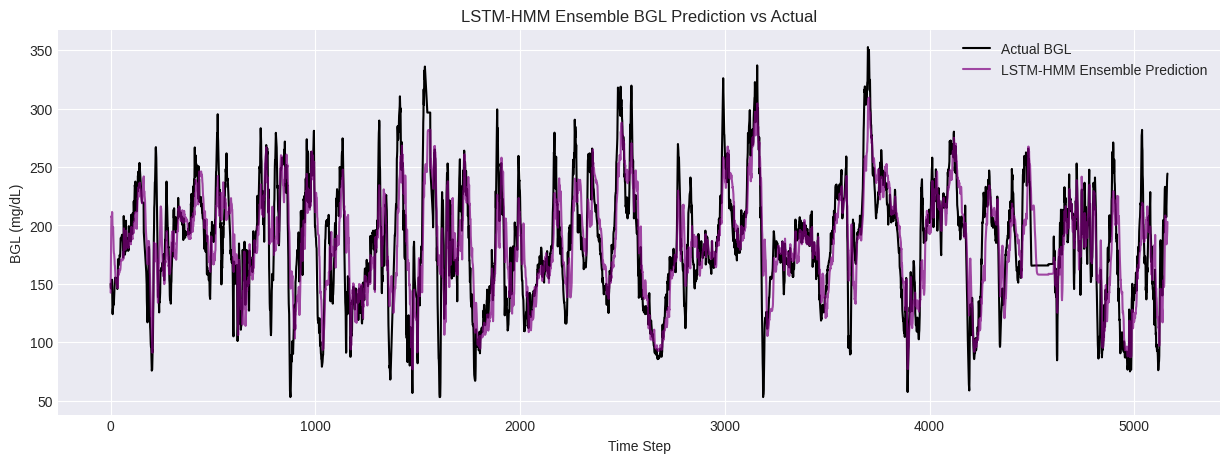

In [83]:
import matplotlib.pyplot as plt

# Plot for LSTM-HMM Ensemble
plt.figure(figsize=(15,5))
plt.plot(y_test_inv_aligned, label='Actual BGL', color='black')
plt.plot(lstm_hmm_ensemble_pred, label='LSTM-HMM Ensemble Prediction', color='purple', alpha=0.7)
plt.title("LSTM-HMM Ensemble BGL Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("BGL (mg/dL)")
plt.legend()
plt.show()

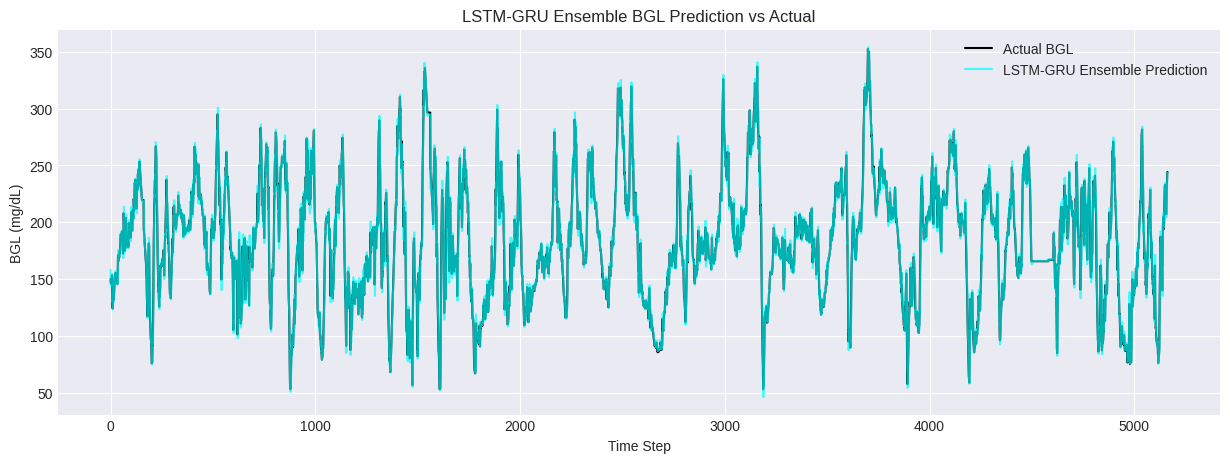

In [84]:
import matplotlib.pyplot as plt

# Plot for LSTM-GRU Ensemble
plt.figure(figsize=(15,5))
plt.plot(y_test_inv_aligned, label='Actual BGL', color='black')
plt.plot(lstm_gru_ensemble_pred, label='LSTM-GRU Ensemble Prediction', color='cyan', alpha=0.7)
plt.title("LSTM-GRU Ensemble BGL Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("BGL (mg/dL)")
plt.legend()
plt.show()

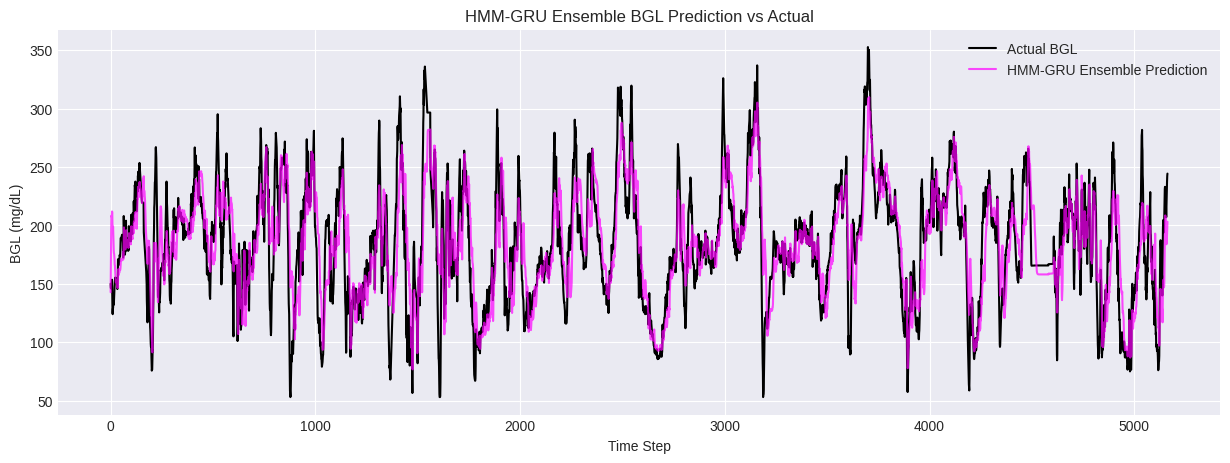

In [85]:
import matplotlib.pyplot as plt

# Plot for HMM-GRU Ensemble
plt.figure(figsize=(15,5))
plt.plot(y_test_inv_aligned, label='Actual BGL', color='black')
plt.plot(hmm_gru_ensemble_pred, label='HMM-GRU Ensemble Prediction', color='magenta', alpha=0.7)
plt.title("HMM-GRU Ensemble BGL Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("BGL (mg/dL)")
plt.legend()
plt.show()

In [90]:
# Create DataFrame
comparison_df = pd.DataFrame(model_metrics)

# Print as a table using tabulate
print("\n--- Model Performance Comparison ---")
print(tabulate(comparison_df, headers='keys', tablefmt='grid', showindex=False))


--- Model Performance Comparison ---
+-------------------+----------+----------+----------+------------+
| Model             |      MAE |     RMSE |     MAPE |   Accuracy |
+===================+==========+==========+==========+============+
| LSTM              |  5.41082 |  7.81053 |  3.13943 |    96.8606 |
+-------------------+----------+----------+----------+------------+
| GRU               |  5.38258 |  7.78495 |  3.12369 |    96.8763 |
+-------------------+----------+----------+----------+------------+
| HMM               |  9.82518 | 13.6548  |  5.94137 |    94.0586 |
+-------------------+----------+----------+----------+------------+
| LSTM-HMM Ensemble | 22.862   | 29.5442  | 14.1682  |    85.8318 |
+-------------------+----------+----------+----------+------------+
| LSTM-GRU Ensemble |  5.38992 |  7.7899  |  3.127   |    96.873  |
+-------------------+----------+----------+----------+------------+
| HMM-GRU Ensemble  | 22.8631  | 29.5666  | 14.1884  |    85.8116 |
+---------